[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/notebooks/L2B2_domain_shift_toy.ipynb)

# Notebook 01 — Domain Shift: Quebrar e Consertar um Classificador
### Treinar, avaliar, quebrar com shift, consertar com transfer learning
**I Escola de Inverno do IFUSP — Bloco L2B2**

> **Modo de uso:** demo guiada pelo instrutor; vocês recebem o notebook depois.
> Ao final, teremos vivenciado todo o ciclo do domain shift num universo 2D
> de brinquedo: treinar um classificador, avaliá-lo com ferramentas ricas,
> observar a degradação quando o domínio muda, e consertá-lo com fine-tuning.

In [1]:
# Instalação de pacotes (só no Colab — localmente já estão instalados)
import subprocess, sys
try:
    import google.colab  # noqa: F401
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "jax", "jaxlib", "equinox", "optax", "matplotlib"])
except ImportError:
    pass

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Semente de reprodutibilidade
SEED = 42
KEY = jax.random.PRNGKey(SEED)

# Estilo dos gráficos
plt.rcParams.update({"figure.dpi": 110,"axes.titlesize": 12,"axes.labelsize": 11,"legend.fontsize": 9})

print(f"JAX versão  : {jax.__version__}")
print(f"Dispositivo : {jax.devices()[0]}")

JAX versão  : 0.6.2
Dispositivo : cuda:0


---
## Bloco 1 — Gerador de dados 2D (domínio fonte)

Criamos um problema de classificação 2D com **3 classes desbalanceadas**:

| Classe | Fração |
|--------|--------|
| 0 (majoritária) | 50 % |
| 1 (intermediária) | 30 % |
| 2 (minoritária) | 20 % |

As classes se **sobrepõem parcialmente** — gerando erros reais de
classificação — e têm **covariâncias diferentes**, o que força fronteiras
de decisão não-lineares.

**Por que desbalancear?** Em problemas reais,
as classes raras são as mais fáceis de
ignorar durante o treino.

In [ ]:
# --- Configuração das classes ---------------------------------------------
N_CLASSES     = 3
NOMES_CLASSES = ["Classe 0", "Classe 1", "Classe 2"]
CORES_CLASSES = [ # Okabe-Ito for colorblind
    "#E69F00",  # Orange
    "#56B4E9",  # Sky Blue
    "#009E73",  # Bluish Green
    "#F0E442",  # Yellow
    "#0072B2",  # Blue
    "#D55E00",  # Vermillion (Reddish Orange)
    "#CC79A7",  # Reddish Purple
    "#000000",  # Black
    "#999999",  # 9.
    "#553388"   # 10.
]
FRACOES       = np.array([0.50, 0.30, 0.20])          # classes desbalanceadas

# --- Duas primitivas geométricas ------------------------------------------
def _arco(chave, n, centro, raio, ang, esp):
    """Arco de círculo: ang=(ini, fim) em graus, esp = espessura radial."""
    k_t, k_r = jax.random.split(chave)
    th = jax.random.uniform(k_t, (n,), minval=jnp.deg2rad(ang[0]), maxval=jnp.deg2rad(ang[1]))
    r  = raio + esp * jax.random.normal(k_r, (n,))
    return jnp.stack([r * jnp.cos(th), r * jnp.sin(th)], -1) + jnp.array(centro)

def _mancha(chave, n, centro, escala, rotacao=0.0):
    """Mancha gaussiana: escala=(sx, sy), rotacao em graus."""
    a = jnp.deg2rad(rotacao)
    R = jnp.array([[jnp.cos(a), -jnp.sin(a)], [jnp.sin(a), jnp.cos(a)]])
    z = jax.random.normal(chave, (n, 2)) * jnp.array(escala)
    return z @ R.T + jnp.array(centro)

# --- Especificação do domínio FONTE ---------------------------------------
ESPEC_FONTE = [
    # Classe 0: arco grande em "C"
    [dict(peso=1.0, tipo="arco", centro=(0.0, 0.4), raio=3.0, ang=(55, 305), esp=0.30)],
    # Classe 1: arco menor, entrelaçado com o "C"
    [dict(peso=1.0, tipo="arco", centro=(1.6, -0.6), raio=1.9, ang=(-40, 200), esp=0.28)],
    # Classe 2 (rara): núcleo bimodal dentro do "C"
    [dict(peso=0.6, tipo="mancha", centro=(-0.5, 0.6), escala=(0.55, 0.40)), dict(peso=0.4, tipo="mancha", centro=(0.6, -1.0), escala=(0.45, 0.35), rotacao=40.0)],
]

def _amostra(chave, n, comp):
    if comp["tipo"] == "arco":
        return _arco(chave, n, comp["centro"], comp["raio"], comp["ang"], comp["esp"])
    return _mancha(chave, n, comp["centro"], comp["escala"], comp.get("rotacao", 0.0))

def gerar_dados(n_total, espec, fracoes, chave):
    """Gera mistura de formas 2D com classes desbalanceadas.
    Retorna X (n_total, 2) e y (n_total,) como arrays JAX."""
    Xs, ys = [], []
    for c, comps in enumerate(espec):
        n_c   = int(n_total * fracoes[c])
        pesos = np.array([k["peso"] for k in comps]); pesos = pesos / pesos.sum()
        ns    = np.floor(n_c * pesos).astype(int); ns[-1] += n_c - ns.sum()
        for comp, n_k in zip(comps, ns):
            chave, k = jax.random.split(chave)
            Xs.append(_amostra(k, int(n_k), comp))
            ys.append(jnp.full(int(n_k), c, jnp.int32))
    X, y = jnp.concatenate(Xs).astype(jnp.float32), jnp.concatenate(ys)
    chave, k = jax.random.split(chave)
    perm = jax.random.permutation(k, X.shape[0])
    return X[perm], y[perm]

# --- Gerar dados fonte: treino + validação --------------------------------
N_TREINO, N_VAL = 10000, 5000
key_src_tr, key_src_val, KEY = jax.random.split(KEY, 3)
X_treino, y_treino = gerar_dados(N_TREINO, ESPEC_FONTE, FRACOES, key_src_tr)
X_val,    y_val    = gerar_dados(N_VAL,    ESPEC_FONTE, FRACOES, key_src_val)

print(f"Treino: {X_treino.shape[0]} pontos | Validação: {X_val.shape[0]} pontos")
for c in range(N_CLASSES):
    print(f"  {NOMES_CLASSES[c]}: {int((y_treino==c).sum())} treino, {int((y_val==c).sum())} val")

Treino: 10000 pontos | Validação: 5000 pontos
  Classe 0: 5000 treino, 2500 val
  Classe 1: 3000 treino, 1500 val
  Classe 2: 2000 treino, 1000 val


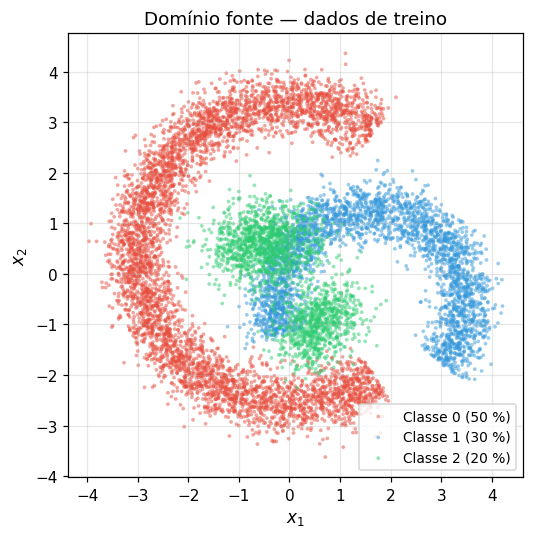

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for c in range(N_CLASSES):
    mask = y_treino == c
    ax.scatter(X_treino[mask, 0], X_treino[mask, 1], s=6, color=CORES_CLASSES[c], alpha=0.5, edgecolors="none", label=f"{NOMES_CLASSES[c]} ({int(FRACOES[c]*100)} %)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Domínio fonte — dados de treino")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## Bloco 2 — Treinar um classificador (Equinox + Optax)

Usamos a mesma receita do Notebook 00:

- **Equinox** define o modelo como módulo.
- **Optax** fornece o otimizador (Adam).

In [ ]:
class Classificador(eqx.Module):
    """MLP classificador com camadas de tamanho variável."""
    layers: list

    def __init__(self, camadas, key):
        self.layers = []
        for i in range(len(camadas) - 1):
            key, subkey = jax.random.split(key)
            self.layers.append(eqx.nn.Linear(camadas[i], camadas[i + 1], key=subkey))

    def __call__(self, x):
        """Forward pass: tanh nas ocultas, linear na saída."""
        for layer in self.layers[:-1]:
            x = jnp.tanh(layer(x))
        return self.layers[-1](x)

# Criar modelo
CAMADAS = [2, 16, 16, 16, N_CLASSES]
modelo = Classificador(CAMADAS, key=jax.random.PRNGKey(0))

# Teste rápido
y_teste = jax.vmap(modelo)(X_treino[:3])
print(f"Entrada: shape {X_treino[:3].shape}")
print(f"Saída (logits): shape {y_teste.shape}")
n_params = sum(jnp.size(p) for p in jax.tree_util.tree_leaves(modelo))
print(f"Total de parâmetros: {n_params}")

Entrada: shape (3, 2)
Saída (logits): shape (3, 3)
Total de parâmetros: 643


### Entropia Cruzada Ponderada (Weighted Cross-Entropy)

A perda de entropia cruzada ponderada ajusta a contribuição de cada amostra com base na frequência da sua classe, penalizando mais os erros em classes minoritárias.

#### Equação Principal
Para um *batch* de tamanho $N$ e $C$ classes, a perda é definida como:

$$
\mathcal{L}_{\text{WCE}} = -\frac{1}{N} \sum_{n=1}^{N} w_{y_n} \log \hat{y}_{n, y_n}
$$

#### Cálculo dos Pesos
Os pesos $w_c$ são calculados como o inverso da frequência da classe ($\pi_c$), normalizados para que sua média seja 1 (preservando a escala da perda):

$$
w_c = \frac{C \cdot \pi_c^{-1}}{\sum_{k=1}^{C} \pi_k^{-1}}
$$

#### Notação
- $N$: Tamanho do *batch*.
- $C$: Número total de classes.
- $y_n$: Rótulo verdadeiro (índice da classe) da amostra $n$.
- $\hat{y}_{n, y_n}$: Probabilidade predita pelo modelo para a classe verdadeira $y_n$ (obtida via `log_softmax` para estabilidade numérica).
- $w_{y_n}$: Peso escalar associado à classe $y_n$.

In [ ]:
# Pesos de classe: inverso da frequência, normalizados
pesos_classe = jnp.array(1.0 / FRACOES)
pesos_classe = pesos_classe / pesos_classe.sum() * N_CLASSES
print(f"Pesos de classe: {pesos_classe}")

def perda_ce_ponderada(modelo, x_batch, y_batch):
    """Entropia cruzada ponderada por classe."""
    logits = jax.vmap(modelo)(x_batch)
    log_p = jax.nn.log_softmax(logits, axis=-1)
    N = y_batch.shape[0]
    log_py = log_p[jnp.arange(N), y_batch]
    pesos = pesos_classe[y_batch]
    return -jnp.mean(pesos * log_py)

Pesos de classe: [0.5806452  0.96774197 1.451613  ]


In [7]:
# Otimizador e passo de treino
otimizador = optax.adam(learning_rate=1e-3)
opt_state = otimizador.init(eqx.filter(modelo, eqx.is_array))

@eqx.filter_jit
def passo_treino(modelo, estado, x, y):
    """Um passo: gradiente + atualização Adam."""
    perda, grads = eqx.filter_value_and_grad(perda_ce_ponderada)(modelo, x, y)
    atualizacoes, estado = otimizador.update(grads, estado, modelo)
    modelo = eqx.apply_updates(modelo, atualizacoes)
    return modelo, estado, perda

In [8]:
# Loop de treino com mini-batches
N_EPOCAS = 100
BATCH_SIZE = 1024

historico_treino = []
historico_val = []
chave_treino = jax.random.PRNGKey(1)

print(f"Treinando {N_EPOCAS} épocas — Adam (lr=3e-3, batch={BATCH_SIZE})")

for epoca in range(1, N_EPOCAS + 1):
    chave_treino, chave_perm = jax.random.split(chave_treino)
    perm = jax.random.permutation(chave_perm, X_treino.shape[0])
    X_emb = X_treino[perm]
    y_emb = y_treino[perm]

    for i in range(0, X_treino.shape[0], BATCH_SIZE):
        x_b = X_emb[i:i + BATCH_SIZE]
        y_b = y_emb[i:i + BATCH_SIZE]
        modelo, opt_state, _ = passo_treino(modelo, opt_state, x_b, y_b)

    if epoca % 1 == 0 or epoca == 1:
        p_tr = float(perda_ce_ponderada(modelo, X_treino, y_treino))
        p_va = float(perda_ce_ponderada(modelo, X_val, y_val))
        historico_treino.append((epoca, p_tr))
        historico_val.append((epoca, p_va))
        if epoca <= 1 or epoca % 10 == 0:
            print(f"  Época {epoca:4d}  treino={p_tr:.4f}  val={p_va:.4f}")

print("Treino concluído.")

Treinando 100 épocas — Adam (lr=3e-3, batch=1024)
  Época    1  treino=0.9483  val=0.9478
  Época   10  treino=0.6763  val=0.6718
  Época   20  treino=0.3785  val=0.3736
  Época   30  treino=0.2718  val=0.2678
  Época   40  treino=0.2328  val=0.2271
  Época   50  treino=0.1972  val=0.1913
  Época   60  treino=0.1720  val=0.1660
  Época   70  treino=0.1595  val=0.1537
  Época   80  treino=0.1525  val=0.1472
  Época   90  treino=0.1489  val=0.1441
  Época  100  treino=0.1466  val=0.1419
Treino concluído.


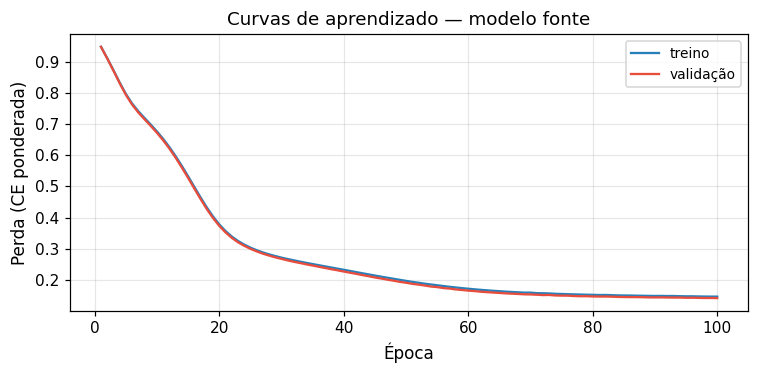

In [9]:
# Curvas de aprendizado
ep_tr, l_tr = zip(*historico_treino)
ep_va, l_va = zip(*historico_val)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ep_tr, l_tr, "-", lw=1.5, color="#2980b9", label="treino")
ax.plot(ep_va, l_va, "-", lw=1.5, color="#e74c3c", label="validação")
ax.set_xlabel("Época")
ax.set_ylabel("Perda (CE ponderada)")
ax.set_title("Curvas de aprendizado — modelo fonte")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Bloco 3 — Avaliação: visualizações e métricas

O modelo treinou. Agora precisamos **entender** o que ele aprendeu.
Vamos construir diferentes ferramentas de avaliação, cada uma revelando um
aspecto do classificador.

### 3a) Mapa de probabilidade

Avaliamos o modelo numa malha densa cobrindo o espaço 2D. Para cada
ponto da malha, calculamos $P(\text{classe } k \mid x)$. Isso mostra
exatamente o que o modelo **acredita** em cada região — inclusive onde
ele está confiante mas errado.

In [10]:
def criar_malha(xlim=(-5.5, 8.5), ylim=(-10.5, 6.5), passo=0.10):
    """Cria malha 2D para avaliação densa."""
    xx, yy = np.meshgrid(np.arange(xlim[0], xlim[1], passo), np.arange(ylim[0], ylim[1], passo))
    return xx, yy

def probabilidades_malha(modelo, xx, yy):
    """Calcula softmax do modelo em todos os pontos da malha."""
    pts = jnp.array(np.c_[xx.ravel(), yy.ravel()], dtype=jnp.float32)
    logits = jax.vmap(modelo)(pts)
    probs = jax.nn.softmax(logits, axis=-1)
    return np.array(probs)

xx, yy = criar_malha()
probs_malha = probabilidades_malha(modelo, xx, yy)

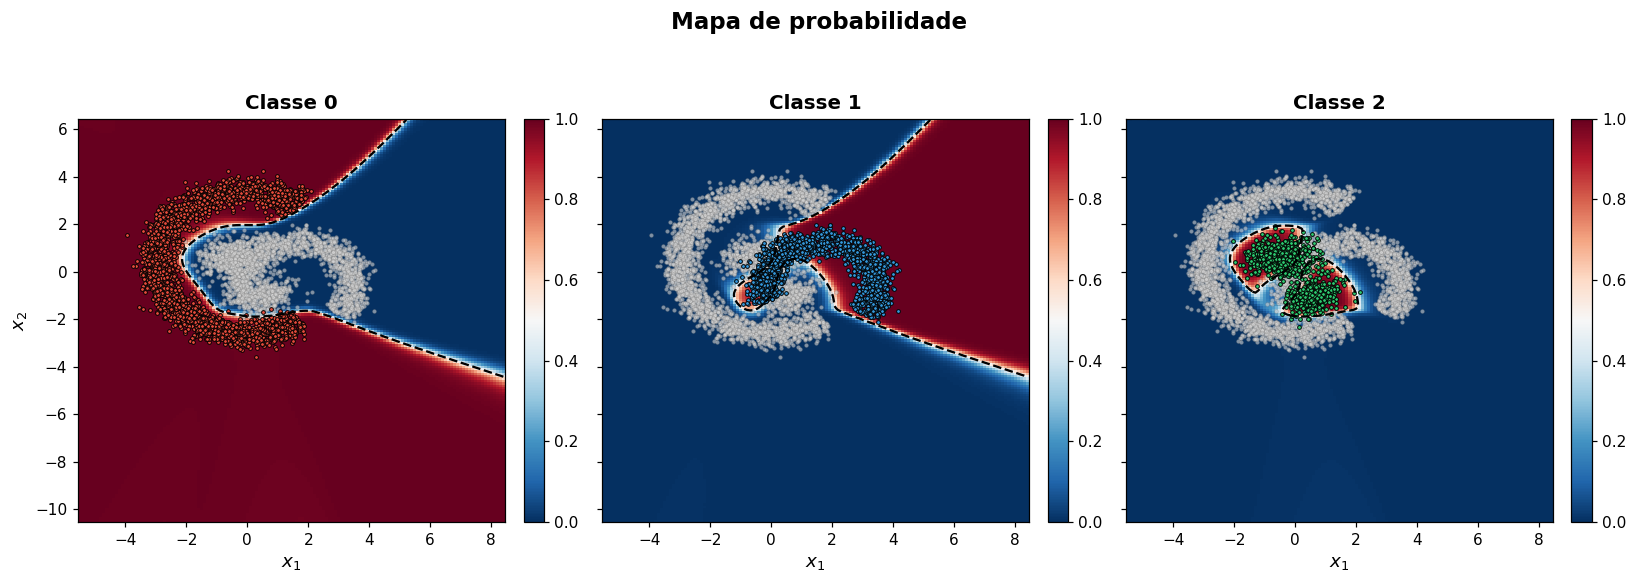

In [11]:
# Mapa de probabilidade — um subpainel por classe
fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 5), sharex=True, sharey=True)
fig.suptitle("Mapa de probabilidade", fontsize=15, fontweight='bold', y=1.05)

for c in range(N_CLASSES):
    P_c = probs_malha[:, c].reshape(xx.shape)
    
    im = axes[c].pcolormesh(xx, yy, P_c, cmap="RdBu_r", shading="auto", vmin=0, vmax=1, rasterized=True)
    axes[c].contour(xx, yy, P_c, levels=[0.5], colors='black', linewidths=1.5, linestyles='dashed', zorder=4)
    
    mask_not = y_val != c
    axes[c].scatter(X_val[mask_not, 0], X_val[mask_not, 1], s=6, color="lightgray", edgecolors="gray", alpha=0.6, linewidths=0.3, zorder=2)
    
    mask = y_val == c
    axes[c].scatter(X_val[mask, 0], X_val[mask, 1], s=6, color=CORES_CLASSES[c], edgecolors="black", linewidths=0.6, zorder=3)
    
    axes[c].set_title(NOMES_CLASSES[c], fontsize=13, fontweight='bold')
    axes[c].set_xlabel("$x_1$", fontsize=12)
    
    if c == 0:
        axes[c].set_ylabel("$x_2$", fontsize=12)
    else:
        axes[c].tick_params(labelleft=False)
        
    axes[c].tick_params(axis='both', which='major', labelsize=10)
    
    plt.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 3b) Mapa de decisão (regiões de classe)

Aplicamos $\arg\max$ nas probabilidades: cada ponto da malha recebe
a classe de maior probabilidade. Isso mostra as **fronteiras de decisão**
aprendidas pelo modelo.

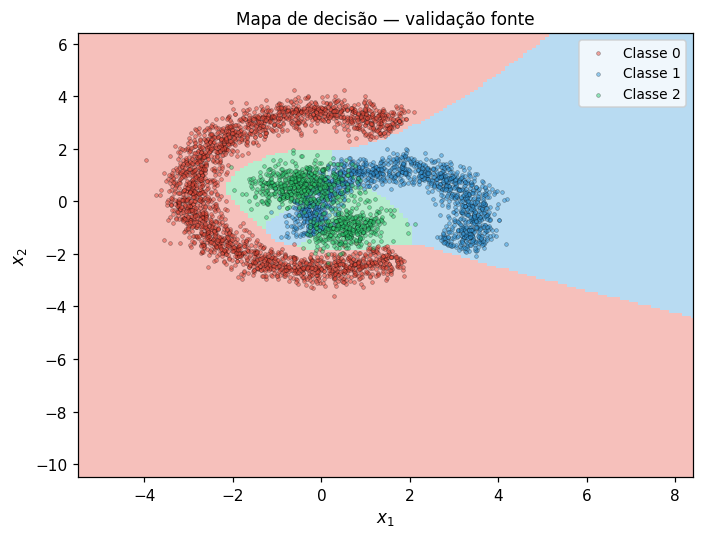

In [12]:
def plotar_mapa_decisao(ax, modelo, X_overlay, y_overlay, titulo, xx, yy, probs=None, alpha_fundo=0.35):
    """Plota regiões de decisão com pontos sobrepostos."""
    if probs is None:
        probs = probabilidades_malha(modelo, xx, yy)
    preds = probs.argmax(axis=1).reshape(xx.shape)

    cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha_fundo) for c in CORES_CLASSES])
    ax.pcolormesh(xx, yy, preds, cmap=cmap_bg, shading="auto", vmin=0, vmax=N_CLASSES - 1)

    for c in range(N_CLASSES):
        mask = y_overlay == c
        ax.scatter(
            np.array(X_overlay[mask, 0]), np.array(X_overlay[mask, 1]), s=6, color=CORES_CLASSES[c],
            edgecolors="k", alpha=0.5, linewidths=0.3, zorder=3, label=NOMES_CLASSES[c]
        )

    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

fig, ax = plt.subplots(figsize=(6.5, 5))
plotar_mapa_decisao(ax, modelo, X_val, y_val, "Mapa de decisão — validação fonte", xx, yy, probs=probs_malha)
ax.legend()
plt.tight_layout()
plt.show()

### 3c) Matriz de confusão e métricas por classe

A **acurácia** global pode ser enganosa com classes desbalanceadas:
se o modelo prever sempre "Classe 0", já terá 50 % de acerto!

Métricas por classe revelam a verdade:

| Métrica | O que mede |
|---------|-----------|
| **TPR** (recall) | Dos exemplos reais da classe, quantos o modelo acertou? |
| **PPV** (precision) | Das predições nessa classe, quantas estavam corretas? |
| **F1** | Média harmônica de TPR e PPV — resume ambos num número |

In [13]:
# ==============================================================================
def calcular_metricas(y_true, y_pred, n_classes):
    """Calcula matriz de confusão, TPR, PPV e F1 por classe de forma vetorizada."""
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    # Matriz de confusão
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    # Cálculos vetorizados
    tp = np.diag(cm)
    fn = cm.sum(axis=1) - tp
    fp = cm.sum(axis=0) - tp
    
    tpr = tp / np.maximum(tp + fn, 1)
    ppv = tp / np.maximum(tp + fp, 1)
    f1 = 2 * tpr * ppv / np.maximum(tpr + ppv, 1e-9)  # Evita divisão por zero
    
    acc = np.trace(cm) / max(cm.sum(), 1)
    return cm, tpr, ppv, f1, acc


# ==============================================================================
def plotar_matriz_confusao(ax, cm, tpr, ppv, f1, class_names, title="Matriz de Confusão"):
    """Plota a matriz de confusão normalizada por linha, com métricas na diagonal."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(cm, row_sums, where=row_sums != 0)
    
    norm = mcolors.Normalize(vmin=0, vmax=1)
    im = ax.imshow(cm_percent, interpolation='nearest', cmap='RdYlGn', norm=norm)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Proporção', rotation=270, labelpad=15, fontsize=11)

    num_classes = len(class_names)
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel('Predito', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")

    threshold_color = 0.5
    for i in range(num_classes):
        for j in range(num_classes):
            count = cm[i, j]
            percent = cm_percent[i, j] * 100 if row_sums[i] != 0 else 0
            text_color = "white" if cm_percent[i, j] > threshold_color else "black"
            
            if i == j:
                text = (f"{count}\n"
                        f"TPR: {tpr[i]*100:.1f}%\n"
                        f"PPV: {ppv[i]*100:.1f}%\n"
                        f"F1:  {f1[i]:.2f}")
                ax.text(j, i, text, ha="center", va="center", 
                        color=text_color, fontsize=9, fontweight='bold')
            else:
                text = f"{count}\n({percent:.1f}%)"
                ax.text(j, i, text, ha="center", va="center", 
                        color=text_color, fontsize=10)


# ==============================================================================
def plotar_radar_metricas(ax, class_names, tpr, ppv, f1, title="Métricas por Classe"):
    """Plota TPR, PPV e F1 em um gráfico de radar para comparação visual."""
    C = len(class_names)
    angles = np.linspace(0, 2 * np.pi, C, endpoint=False).tolist()
    angles_closed = angles + [angles[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(class_names, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=25)

    def plot_series(values, color, marker, label):
        vals_closed = list(values) + [values[0]]
        ax.plot(angles_closed, vals_closed, color=color, linewidth=2.5, 
                marker=marker, markersize=7, label=label, zorder=3)
        ax.fill(angles_closed, vals_closed, color=color, alpha=0.15, zorder=2)

    plot_series(tpr, color="#3498db", marker="o", label="TPR (Recall)")
    plot_series(ppv, color="#e74c3c", marker="s", label="PPV (Precision)")
    plot_series(f1,  color="#2ecc71", marker="^", label="F1-Score")

    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.05), fontsize=11, frameon=True, shadow=True)

In [14]:
_logits = jax.vmap(modelo)(X_val)
probs_val = jax.nn.softmax(_logits, axis=-1)
y_val_model = jnp.argmax(probs_val, axis=-1)

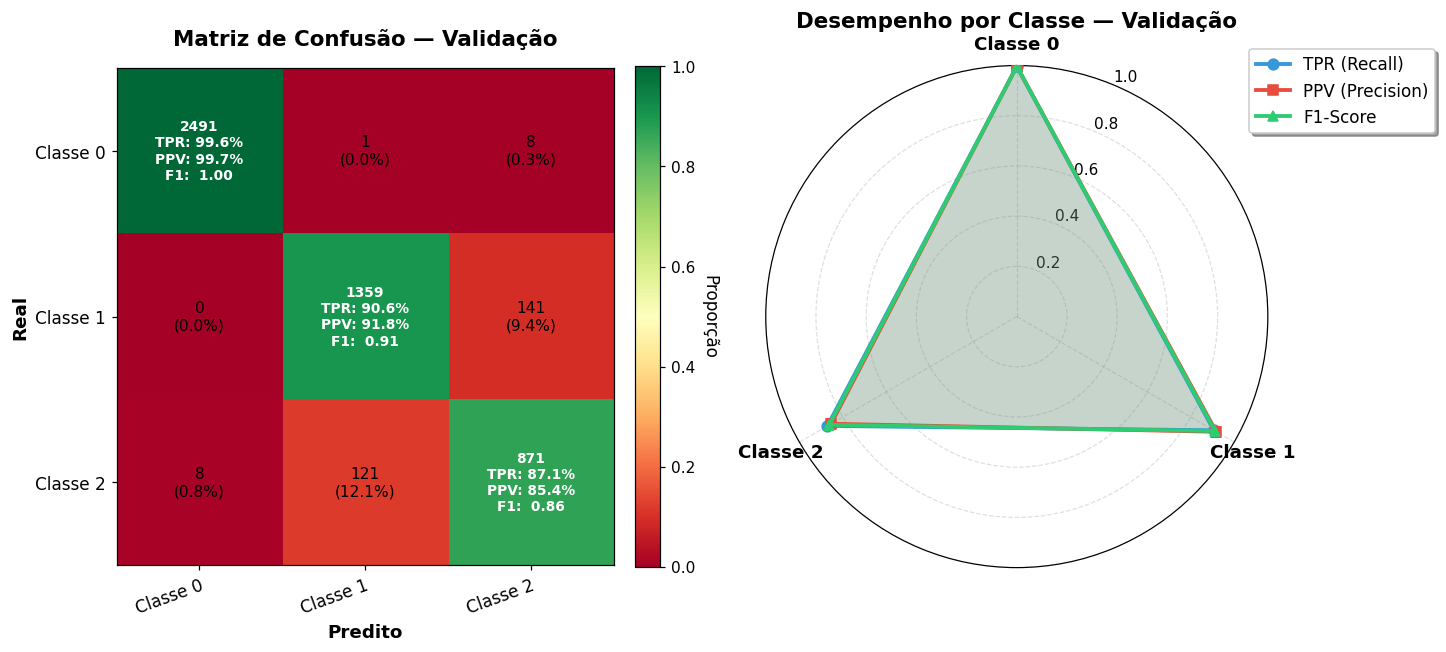

Acurácia Global : 0.944
Macro-F1        : 0.924
Classe 0        | TPR: 0.996  |  PPV: 0.997  |  F1: 0.997
Classe 1        | TPR: 0.906  |  PPV: 0.918  |  F1: 0.912
Classe 2        | TPR: 0.871  |  PPV: 0.854  |  F1: 0.862


In [ ]:
# 1. Converter para NumPy (garante compatibilidade total com Matplotlib/NumPy)
y_true_np = np.array(y_val)
y_pred_np = np.array(y_val_model)

# 2. Calcular métricas usando os dados reais
cm_fonte, tpr_fonte, ppv_fonte, f1_fonte, acc_fonte = calcular_metricas(y_true=y_true_np, y_pred=y_pred_np, n_classes=N_CLASSES)

# 3. Criar figura com 2 subplots (1 cartesiano, 1 polar)
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, polar=True)

# 4. Plotar os gráficos
plotar_matriz_confusao(
    ax=ax1, cm=cm_fonte, tpr=tpr_fonte, ppv=ppv_fonte, f1=f1_fonte, class_names=NOMES_CLASSES, title="Matriz de Confusão — Validação"
)

plotar_radar_metricas(
    ax=ax2, class_names=NOMES_CLASSES, tpr=tpr_fonte, ppv=ppv_fonte, f1=f1_fonte, title="Desempenho por Classe — Validação"
)

# Ajuste final de layout (o rect=[0, 0, 0.95, 1] dá espaço à direita para a legenda do radar)
plt.tight_layout(rect=[0, 0, 0.95, 1]) 
plt.show()

# 5. Saída textual no console
print(f"{'='*50}")
print(f"Acurácia Global : {acc_fonte:.3f}")
print(f"Macro-F1        : {f1_fonte.mean():.3f}")
print(f"{'='*50}")
for c in range(N_CLASSES):
    print(f"{NOMES_CLASSES[c]:<15} | TPR: {tpr_fonte[c]:.3f}  |  PPV: {ppv_fonte[c]:.3f}  |  F1: {f1_fonte[c]:.3f}")

In [16]:
from matplotlib.lines import Line2D

def plotar_mapa_decisao_com_erro(
    fig, axes, xx, yy, probs_malha, X_val, y_val, y_pred_val, 
    nomes_classes, titulo_global="Análise de Erros: Mapa de Decisão One-vs-Rest"
):
    """
    Plota painéis (um por classe) com mapa de probabilidade, 
    fronteira de decisão (50%) e pontos coloridos por TP, TN, FP, FN.
    Inclui contagens de cada métrica no título de cada painel.
    """
    N_CLASSES = len(nomes_classes)
    
    # Conversão segura para NumPy (evita conflitos de backend JAX/Matplotlib)
    X_val_np = np.asarray(X_val)
    y_val_np = np.asarray(y_val)
    y_pred_np = np.asarray(y_pred_val)
    
    # Cores semânticas acessíveis e com bom contraste
    COR_TP = "#27ae60"  # Verde: Acertou que era da classe
    COR_TN = "#bdc3c7"  # Cinza claro: Acertou que NÃO era da classe (fundo)
    COR_FP = "#e74c3c"  # Vermelho: Errou, disse que era mas não é (Alarme Falso)
    COR_FN = "#FFA500"  # Azul: Errou, era da classe mas o modelo não disse (Omissão)

    for c in range(N_CLASSES):
        ax = axes[c]
        
        # 1. Mapa de calor da probabilidade da classe c
        P_c = probs_malha[:, c].reshape(xx.shape)
        im = ax.pcolormesh(xx, yy, P_c, cmap="RdBu_r", shading="auto", 
                           vmin=0, vmax=1, rasterized=True, zorder=1)
        
        # 2. Linha de contorno da fronteira de decisão (Probabilidade = 50%)
        ax.contour(xx, yy, P_c, levels=[0.5], colors='black', 
                   linewidths=1.5, linestyles='dashed', zorder=3)
        
        # 3. Máscaras lógicas para TP, TN, FP, FN (perspectiva One-vs-Rest)
        is_true_c = (y_val_np == c)
        is_pred_c = (y_pred_np == c)
        
        mask_TP = is_true_c & is_pred_c
        mask_TN = ~is_true_c & ~is_pred_c
        mask_FP = ~is_true_c & is_pred_c
        mask_FN = is_true_c & ~is_pred_c
        
        # Contagens para o título (enriquecimento conceitual)
        n_TP, n_TN = mask_TP.sum(), mask_TN.sum()
        n_FP, n_FN = mask_FP.sum(), mask_FN.sum()
        
        # 4. Plotagem dos pontos com hierarquia visual (zorder) e tamanhos distintos
        # TN: Fundo, menor e transparente para não poluir o gráfico
        ax.scatter(X_val_np[mask_TN, 0], X_val_np[mask_TN, 1], 
                   s=8, color=COR_TN, edgecolors="#7f8c8d", alpha=0.6, 
                   linewidths=0.3, zorder=2)
        
        # FN: Omissão (Destaque de erro)
        ax.scatter(X_val_np[mask_FN, 0], X_val_np[mask_FN, 1], 
                   s=30, color=COR_FN, edgecolors="black", linewidths=0.8, zorder=4)
        
        # FP: Alarme falso (Destaque de erro)
        ax.scatter(X_val_np[mask_FP, 0], X_val_np[mask_FP, 1], 
                   s=30, color=COR_FP, edgecolors="black", linewidths=0.8, zorder=4)
        
        # TP: Destaque positivo (Acerto)
        ax.scatter(X_val_np[mask_TP, 0], X_val_np[mask_TP, 1], 
                   s=8, color=COR_TP, edgecolors="black", linewidths=0.6, zorder=5)
        
        # 5. Configuração do subpainel
        # Título enriquecido com as contagens absolutas
        ax.set_title(
            f"{nomes_classes[c]}\n(TP:{n_TP} | TN:{n_TN} | FP:{n_FP} | FN:{n_FN})", 
            fontsize=12, fontweight='bold', linespacing=1.4
        )
        ax.set_xlabel("$x_1$", fontsize=11)
        
        if c == 0:
            ax.set_ylabel("$x_2$", fontsize=11)
        else:
            ax.tick_params(labelleft=False) # Esconde números do eixo Y para limpar o visual
            
        ax.tick_params(axis='both', which='major', labelsize=10)
        
        # Colorbar padronizada
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Título global
    fig.suptitle(titulo_global, fontsize=15, fontweight='bold', y=1.05)
    
    # Legenda global unificada para os 4 tipos de resultado
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='TP (Verdadeiro Positivo)', 
               markerfacecolor=COR_TP, markersize=6, markeredgecolor='black', linewidth=1.5),
        Line2D([0], [0], marker='o', color='w', label='TN (Verdadeiro Negativo - Fundo)', 
               markerfacecolor=COR_TN, markersize=6, markeredgecolor='#7f8c8d', linewidth=1.5),
        Line2D([0], [0], marker='o', color='w', label='FP (Falso Positivo - Alarme)', 
               markerfacecolor=COR_FP, markersize=8, markeredgecolor='black', linewidth=1.5),
        Line2D([0], [0], marker='o', color='w', label='FN (Falso Negativo - Omissão)', 
               markerfacecolor=COR_FN, markersize=8, markeredgecolor='black', linewidth=1.5)
    ]
    
    # Ajuste fino para a legenda não cortar a figura (deixa espaço embaixo)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
               fontsize=11, frameon=True, shadow=True, borderpad=0.8)

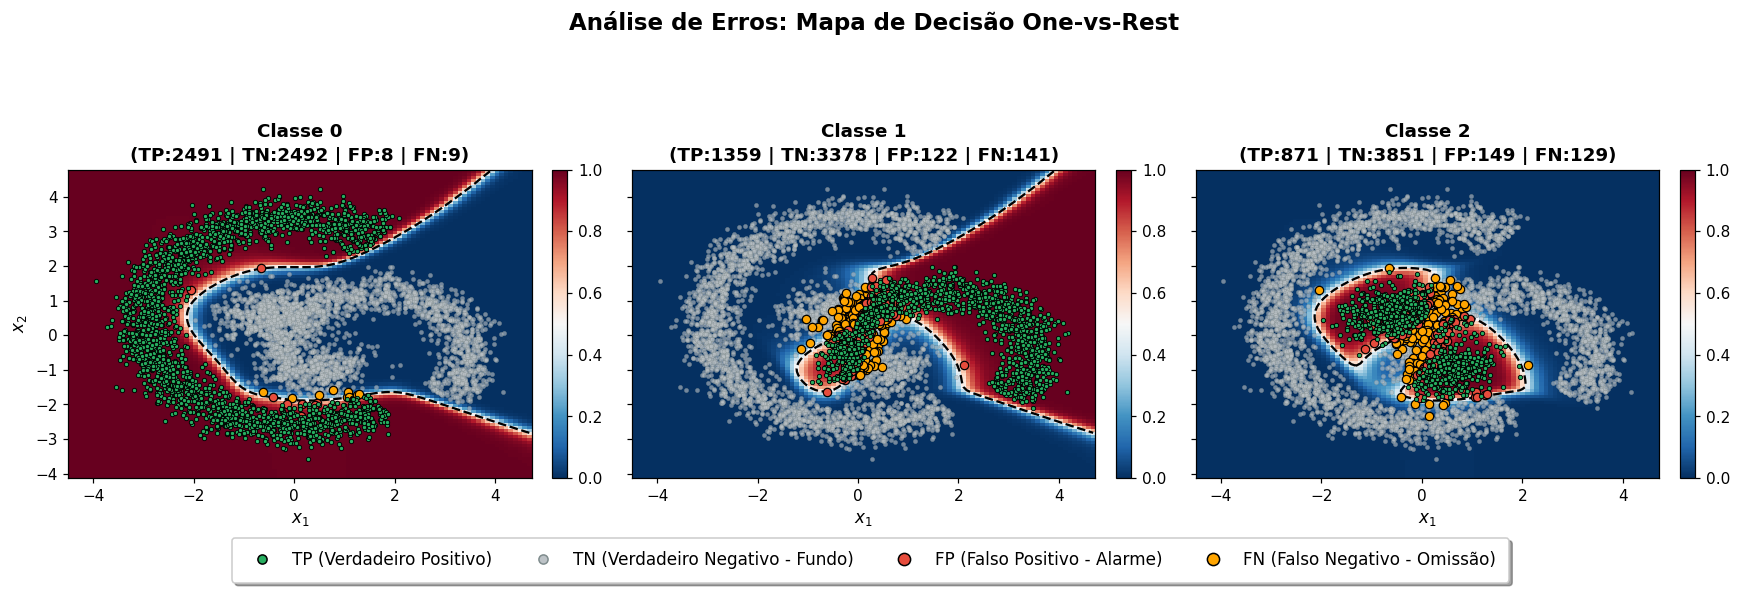

In [17]:
x1_min, x1_max = np.asarray(X_val)[:, 0].min() - 0.5, np.asarray(X_val)[:, 0].max() + 0.5
x2_min, x2_max = np.asarray(X_val)[:, 1].min() - 0.5, np.asarray(X_val)[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
X_malha = np.c_[xx.ravel(), yy.ravel()]

logits_malha = jax.vmap(modelo)(X_malha)
probs_malha = np.array(jax.nn.softmax(logits_malha, axis=-1))

fig, axes = plt.subplots(1, N_CLASSES, figsize=(16, 5))
plotar_mapa_decisao_com_erro(
    fig=fig,axes=axes,xx=xx,yy=yy,probs_malha=probs_malha,X_val=X_val,y_val=y_val,y_pred_val=y_val_model,
    nomes_classes=NOMES_CLASSES,titulo_global="Análise de Erros: Mapa de Decisão One-vs-Rest"
)
plt.show()

### 3d) Curva ROC e AUC (por classe, one-vs-rest)

A curva ROC mostra o trade-off entre **taxa de verdadeiro positivo**
(TPR) e **taxa de falso positivo** (FPR) ao variar o limiar de decisão.

- **AUC = 1.0**: separação perfeita.
- **AUC = 0.5**: classificador aleatório (a diagonal).

A AUC captura o que a acurácia não captura: quão bem o modelo *ordena*
as probabilidades, independentemente do limiar escolhido.

In [18]:
def calcular_roc_auc(y_true, probs, n_classes=N_CLASSES):
    """Calcula curva ROC e AUC por classe (one-vs-rest).

    Trata o caso degenerado (classe ausente no conjunto) retornando None.
    """
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    resultados = []

    for c in range(n_classes):
        y_bin = (y_true == c).astype(int)
        # Caso degenerado: todos da mesma classe
        if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
            resultados.append({"fpr": None, "tpr": None, "auc": None})
            continue

        scores = probs[:, c]
        # Ordenar por score decrescente
        ordem = np.argsort(-scores)
        y_sorted = y_bin[ordem]
        scores_sorted = scores[ordem]

        # Calcular TPR e FPR para cada limiar único
        n_pos = y_bin.sum()
        n_neg = len(y_bin) - n_pos

        tpr_list = [0.0]
        fpr_list = [0.0]
        tp_acum = 0
        fp_acum = 0

        for i in range(len(y_sorted)):
            if y_sorted[i] == 1:
                tp_acum += 1
            else:
                fp_acum += 1
            if i == len(y_sorted) - 1 or scores_sorted[i] != scores_sorted[i + 1]:
                tpr_list.append(tp_acum / n_pos)
                fpr_list.append(fp_acum / n_neg)

        fpr_arr = np.array(fpr_list)
        tpr_arr = np.array(tpr_list)

        # AUC via regra do trapézio
        auc_val = float(np.trapezoid(tpr_arr, fpr_arr))
        resultados.append({"fpr": fpr_arr, "tpr": tpr_arr, "auc": auc_val})

    return resultados


def plotar_roc(ax, roc_resultados, titulo):
    """Plota curvas ROC por classe num eixo."""
    for c in range(N_CLASSES):
        r = roc_resultados[c]
        if r["auc"] is not None:
            ax.plot(r["fpr"], r["tpr"], lw=2, color=CORES_CLASSES[c], label=f'{NOMES_CLASSES[c]} (AUC={r["auc"]:.3f})')
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Aleatório (0.5)")
    ax.set_xlabel("Taxa de Falso Positivo (FPR)")
    ax.set_ylabel("Taxa de Verdadeiro Positivo (TPR)")
    ax.set_title(titulo)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

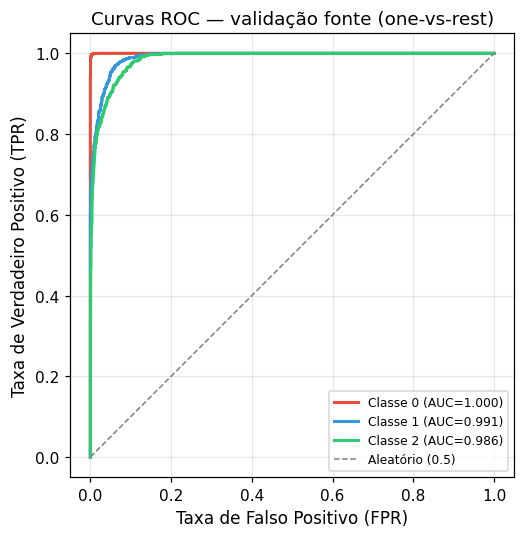

  Classe 0: AUC = 1.000
  Classe 1: AUC = 0.991
  Classe 2: AUC = 0.986
Verificação OK: todos os AUC finitos (guarda contra slices de classe única funcionando).


In [ ]:
# ROC/AUC para o modelo fonte na validação
probs_val_fonte = np.array(jax.nn.softmax(jax.vmap(modelo)(X_val), axis=-1))
roc_fonte = calcular_roc_auc(np.array(y_val), probs_val_fonte)

fig, ax = plt.subplots(figsize=(5.5, 5))
plotar_roc(ax, roc_fonte, "Curvas ROC — validação fonte (one-vs-rest)")
plt.tight_layout()
plt.show()

# Verificação numérica: guarda contra AUC degenerado
for c in range(N_CLASSES):
    auc_val = roc_fonte[c]["auc"]
    assert auc_val is not None and np.isfinite(auc_val), \
        f"AUC degenerado na classe {c}!"
    print(f"  {NOMES_CLASSES[c]}: AUC = {auc_val:.3f}")

---
## Bloco 4 — Introduzindo o domain shift

Agora geramos dados de um **domínio alvo** (target) onde as distribuições
mudaram. O shift é mais complexo do que uma simples translação — além
de deslocar os centros, as **formas** das nuvens também
mudam

In [ ]:
import copy

# ==============================================================================
# Parâmetros do domínio ALVO — classes 1 e 2 levemente deslocadas/deformadas
# Estratégia: manter Classe 0 idêntica (âncora) e aplicar shift suave nas demais
# para criar um domain shift realista mas não catastrófico.
ESPEC_ALVO = copy.deepcopy(ESPEC_FONTE)

# --- Classe 0: sem mudança (mantém a especificação do fonte) ---
# (Nada a fazer — serve como âncora de referência)

# --- Classe 1: arco deslocado para cima-esquerda, levemente mais largo ---
comp = ESPEC_ALVO[1][0]
# Deslocamento do centro (shift horizontal e vertical)
comp["centro"] = (comp["centro"][0] - 0.8, comp["centro"][1] + 0.6)
# Aumento sutil do raio e da espessura (deformação)
comp["raio"]   = comp["raio"] + 0.25
comp["esp"]    = comp["esp"]  * 1.15
# Pequena rotação do intervalo angular (shift na orientação do arco)
ang_ini, ang_fim = comp["ang"]
comp["ang"] = (ang_ini - 10, ang_fim + 8)

# --- Classe 2: núcleo bimodal deslocado para a esquerda e rotacionado ---
# Componente 1 (peso 0.6): mancha principal
comp1 = ESPEC_ALVO[2][0]
comp1["centro"]   = (comp1["centro"][0] - 0.7, comp1["centro"][1] + 0.5)
comp1["escala"]   = (comp1["escala"][0] * 1.20, comp1["escala"][1] * 0.90)
comp1["rotacao"]  = comp1.get("rotacao", 0.0) + 25.0

# Componente 2 (peso 0.4): mancha secundária
comp2 = ESPEC_ALVO[2][1]
comp2["centro"]   = (comp2["centro"][0] - 0.7, comp2["centro"][1] + 0.5)
comp2["escala"]   = (comp2["escala"][0] * 1.15, comp2["escala"][1] * 0.95)
comp2["rotacao"]  = comp2.get("rotacao", 0.0) + 30.0

# ==============================================================================
# Gerar dados do alvo: treino (para fine-tuning) + validação (para avaliação)
N_ALVO_TR  = 5000
N_ALVO_VAL = 5000
key_tgt_tr, key_tgt_val, KEY = jax.random.split(KEY, 3)
X_alvo_tr,  y_alvo_tr  = gerar_dados(N_ALVO_TR,  ESPEC_ALVO, FRACOES, key_tgt_tr)
X_alvo_val, y_alvo_val = gerar_dados(N_ALVO_VAL, ESPEC_ALVO, FRACOES, key_tgt_val)

print(f"Alvo — treino: {X_alvo_tr.shape[0]} pontos  |  validação: {X_alvo_val.shape[0]} pontos")
for c in range(N_CLASSES):
    n_tr = int((y_alvo_tr == c).sum())
    n_va = int((y_alvo_val == c).sum())
    print(f"  {NOMES_CLASSES[c]}: {n_tr} treino, {n_va} val")

Alvo — treino: 5000 pontos  |  validação: 5000 pontos
  Classe 0: 2500 treino, 2500 val
  Classe 1: 1500 treino, 1500 val
  Classe 2: 1000 treino, 1000 val


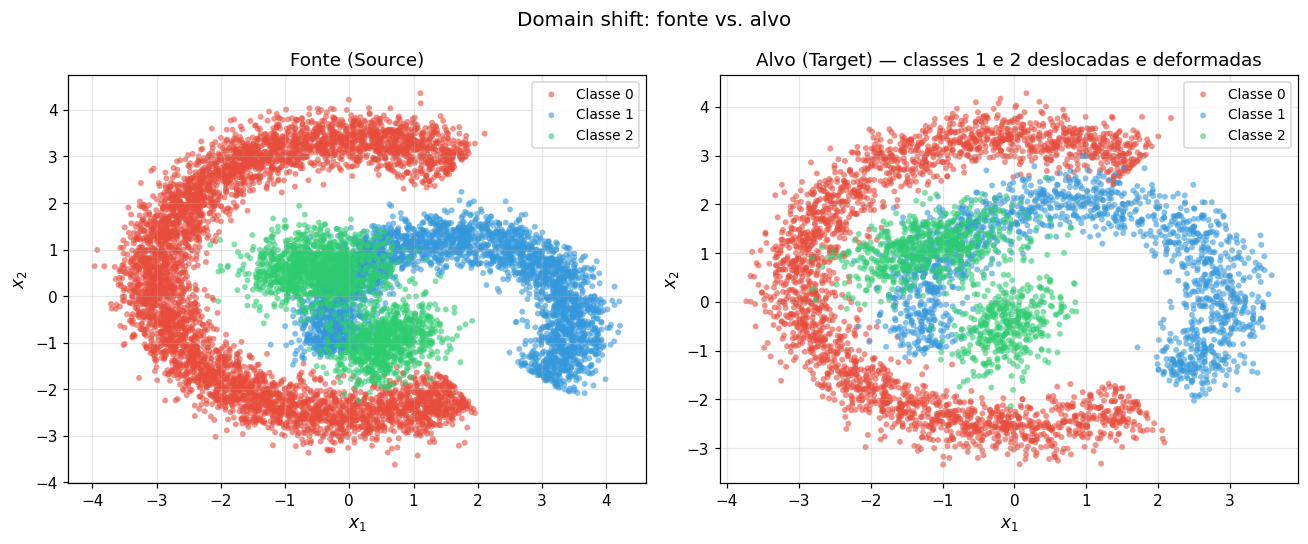

In [21]:
# Figura: fonte vs. alvo lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Domain shift: fonte vs. alvo", fontsize=13)

for c in range(N_CLASSES):
    mask = y_treino == c
    ax1.scatter(X_treino[mask, 0], X_treino[mask, 1], s=15, color=CORES_CLASSES[c], alpha=0.6, edgecolors="none", label=NOMES_CLASSES[c])
ax1.set_title("Fonte (Source)")
ax1.set_xlabel("$x_1$"); ax1.set_ylabel("$x_2$")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

for c in range(N_CLASSES):
    mask = y_alvo_val == c
    ax2.scatter(X_alvo_val[mask, 0], X_alvo_val[mask, 1], s=15, color=CORES_CLASSES[c], alpha=0.6, edgecolors="none", label=NOMES_CLASSES[c])

ax2.set_title("Alvo (Target) — classes 1 e 2 deslocadas e deformadas")
ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Bloco 5 — Quanto o modelo se degrada no alvo?

Aplicamos o modelo fonte (sem nenhuma modificação) aos dados do alvo.
Vamos reutilizar as ferramentas do Bloco 3 para medir a degradação.

In [22]:
# Predições do modelo fonte na validação do alvo
preds_alvo = np.array(jnp.argmax(jax.vmap(modelo)(X_alvo_val), axis=-1))

cm_alvo, tpr_alvo, ppv_alvo, f1_alvo, acc_alvo = calcular_metricas(np.array(y_alvo_val), preds_alvo, n_classes=N_CLASSES)

print("=== Modelo fonte aplicado ao ALVO (validação) ===")
print(f"Acurácia: {acc_alvo:.3f}  (fonte: {acc_fonte:.3f})")
print(f"Macro-F1: {f1_alvo.mean():.3f}  (fonte: {f1_fonte.mean():.3f})")
print()
for c in range(N_CLASSES):
    print(f"  {NOMES_CLASSES[c]}: TPR={tpr_alvo[c]:.3f} (fonte: {tpr_fonte[c]:.3f}) F1={f1_alvo[c]:.3f} (fonte: {f1_fonte[c]:.3f})")

=== Modelo fonte aplicado ao ALVO (validação) ===
Acurácia: 0.787  (fonte: 0.944)
Macro-F1: 0.721  (fonte: 0.924)

  Classe 0: TPR=0.998 (fonte: 0.996) F1=0.946 (fonte: 0.997)
  Classe 1: TPR=0.546 (fonte: 0.906) F1=0.630 (fonte: 0.912)
  Classe 2: TPR=0.624 (fonte: 0.871) F1=0.586 (fonte: 0.862)


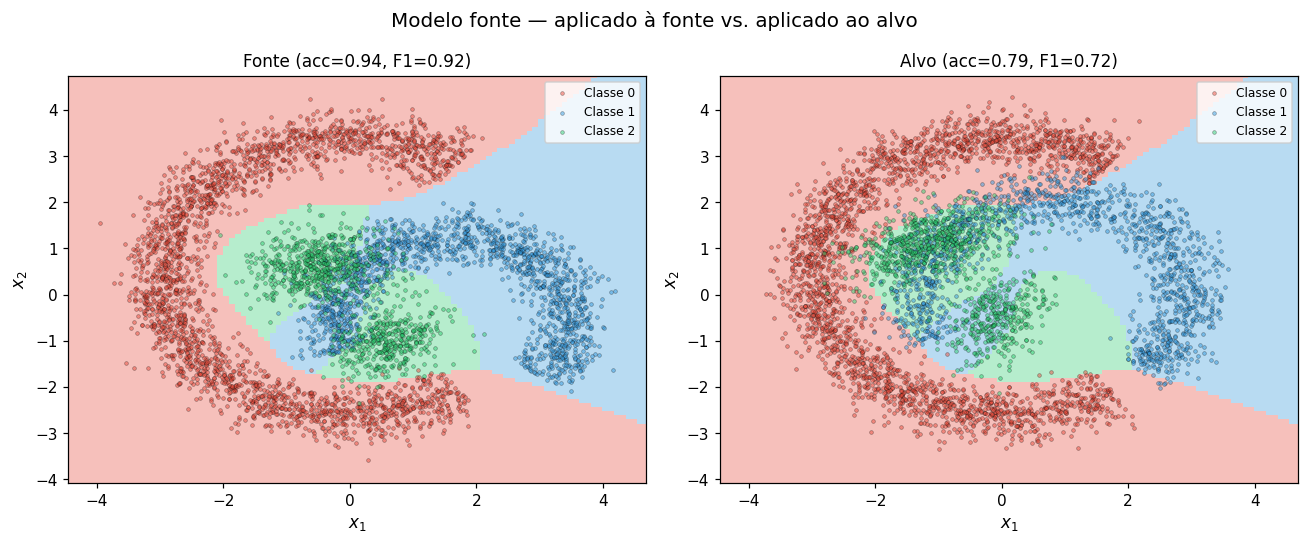

In [23]:
# Mapas de decisão: fonte vs. alvo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Modelo fonte — aplicado à fonte vs. aplicado ao alvo", fontsize=13)

plotar_mapa_decisao(ax1, modelo, X_val, y_val, f"Fonte (acc={acc_fonte:.2f}, F1={f1_fonte.mean():.2f})", xx, yy, probs=probs_malha)
ax1.legend(fontsize=8)

plotar_mapa_decisao(ax2, modelo, X_alvo_val, y_alvo_val, f"Alvo (acc={acc_alvo:.2f}, F1={f1_alvo.mean():.2f})", xx, yy, probs=probs_malha)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

As fronteiras de decisão **não mudaram** (o modelo é o mesmo), mas os
dados do alvo se deslocaram para regiões que o modelo atribui a outras
classes. O modelo está **confiante e errado** — o pior cenário possível.

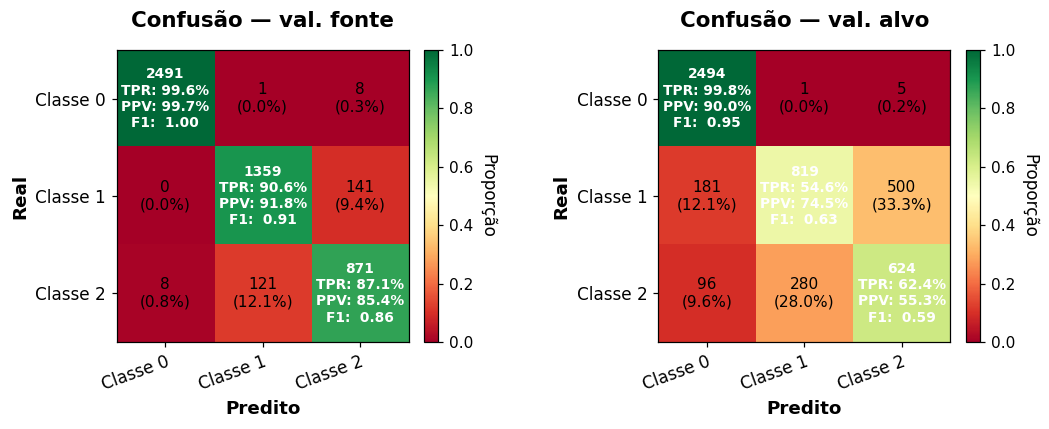

In [24]:
# Matrizes de confusão comparadas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plotar_matriz_confusao(ax1, cm=cm_fonte, tpr=tpr_fonte, ppv=ppv_fonte, f1=f1_fonte, class_names=NOMES_CLASSES, title="Confusão — val. fonte")
plotar_matriz_confusao(ax2, cm=cm_alvo, tpr=tpr_alvo, ppv=ppv_alvo, f1=f1_alvo, class_names=NOMES_CLASSES, title="Confusão — val. alvo")
plt.tight_layout()
plt.show()

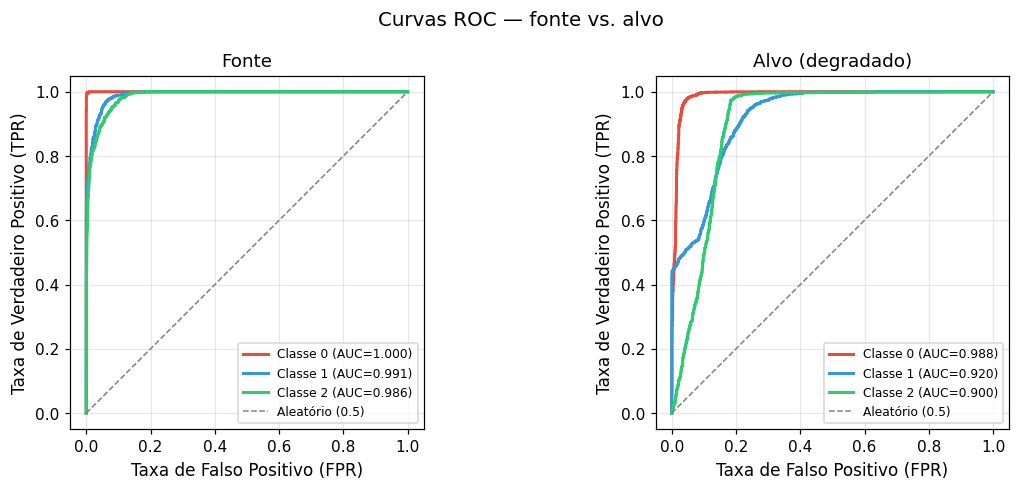


Resumo AUC:
Classe          Fonte     Alvo    Delta
Classe 0        1.000    0.988   -0.012
Classe 1        0.991    0.920   -0.071
Classe 2        0.986    0.900   -0.086


In [25]:
# ROC/AUC no alvo
probs_alvo_full = np.array(jax.nn.softmax(jax.vmap(modelo)(X_alvo_val), axis=-1))
roc_alvo = calcular_roc_auc(np.array(y_alvo_val), probs_alvo_full)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Curvas ROC — fonte vs. alvo", fontsize=13)

plotar_roc(ax1, roc_fonte, "Fonte")
plotar_roc(ax2, roc_alvo, "Alvo (degradado)")

plt.tight_layout()
plt.show()

print("\nResumo AUC:")
print(f"{'Classe':<12} {'Fonte':>8} {'Alvo':>8} {'Delta':>8}")
for c in range(N_CLASSES):
    a_f = roc_fonte[c]["auc"] if roc_fonte[c]["auc"] is not None else 0
    a_a = roc_alvo[c]["auc"] if roc_alvo[c]["auc"] is not None else 0
    print(f"{NOMES_CLASSES[c]:<12} {a_f:>8.3f} {a_a:>8.3f} {a_a - a_f:>+8.3f}")

---
## Bloco 6 — Transfer learning supervisionado (fine-tuning)

Temos um modelo que funciona bem na fonte mas falha no alvo.
A solução mais simples: **fine-tuning** — re-treinar o modelo usando
uma pequena amostra rotulada do domínio alvo.

Concretamente:
- Partimos do modelo já treinado na fonte (todos os pesos).
- Re-treinamos com um learning rate menor e poucos dados do alvo.
- Isso é o **supervised transfer learning** apresentado na teoria (L2B1).

Usamos apenas **K = 500 rótulos do alvo**.

In [ ]:
# Amostrar K rótulos do conjunto de TREINO do alvo (estratificado)
K_ROTULOS = 500

def amostrar_k_rotulos(X, y, K, chave):
    """Amostra K pontos rotulados, estratificado por classe."""
    k_por_classe = max(2, K // N_CLASSES)
    idx_list = []
    for c in range(N_CLASSES):
        idx_c = jnp.where(y == c)[0]
        chave, k = jax.random.split(chave)
        escolhidos = jax.random.permutation(k, idx_c.shape[0])[:k_por_classe]
        idx_list.append(idx_c[escolhidos])
    idx = jnp.concatenate(idx_list)
    return X[idx], y[idx]

key_ft, KEY = jax.random.split(KEY)
X_ft, y_ft = amostrar_k_rotulos(X_alvo_tr, y_alvo_tr, K_ROTULOS, key_ft)
print(f"Amostra para fine-tuning: {X_ft.shape[0]} pontos do treino alvo")
for c in range(N_CLASSES):
    print(f"  {NOMES_CLASSES[c]}: {int((y_ft == c).sum())} pontos")

Amostra para fine-tuning: 3000 pontos do treino alvo
  Classe 0: 1000 pontos
  Classe 1: 1000 pontos
  Classe 2: 1000 pontos


In [27]:
# Fine-tuning: copiar modelo fonte e re-treinar com lr menor

# Copiar o modelo fonte (deep copy dos parâmetros)
modelo_ft = jax.tree.map(lambda x: x, modelo)

# Learning rate menor para fine-tuning (não destruir o que já aprendeu)
otimizador_ft = optax.adam(learning_rate=1e-3)
opt_state_ft = otimizador_ft.init(eqx.filter(modelo_ft, eqx.is_array))

N_EPOCAS_FT = 800
historico_ft = []
chave_ft = jax.random.PRNGKey(7)

@eqx.filter_jit
def passo_ft(modelo, estado, x, y):
    """Passo de fine-tuning."""
    perda, grads = eqx.filter_value_and_grad(perda_ce_ponderada)(modelo, x, y)
    atualizacoes, estado = otimizador_ft.update(grads, estado, modelo)
    modelo = eqx.apply_updates(modelo, atualizacoes)
    return modelo, estado, perda

print(f"Fine-tuning: {N_EPOCAS_FT} épocas, lr=1e-3, K={X_ft.shape[0]} rótulos")

for epoca in range(1, N_EPOCAS_FT + 1):
    chave_ft, chave_perm = jax.random.split(chave_ft)
    perm = jax.random.permutation(chave_perm, X_ft.shape[0])
    modelo_ft, opt_state_ft, perda = passo_ft(modelo_ft, opt_state_ft, X_ft[perm], y_ft[perm])

    if epoca % 25 == 0 or epoca == 1:
        p = float(perda_ce_ponderada(modelo_ft, X_ft, y_ft))
        historico_ft.append((epoca, p))
        if epoca <= 1 or epoca % 200 == 0:
            print(f"  Época {epoca:4d}  perda={p:.4f}")

print("Fine-tuning concluído.")

Fine-tuning: 800 épocas, lr=1e-3, K=3000 rótulos
  Época    1  perda=0.8642
  Época  200  perda=0.2573
  Época  400  perda=0.2375
  Época  600  perda=0.2310
  Época  800  perda=0.2276
Fine-tuning concluído.


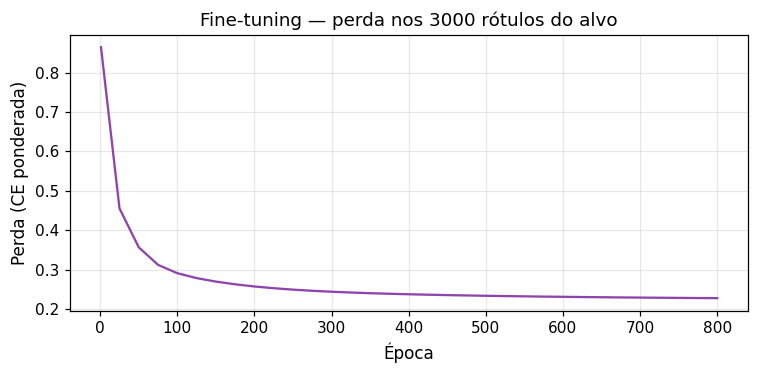

In [28]:
# Curva de perda do fine-tuning
ep_ft, l_ft = zip(*historico_ft)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ep_ft, l_ft, "-", lw=1.5, color="#8e44ad")
ax.set_xlabel("Época")
ax.set_ylabel("Perda (CE ponderada)")
ax.set_title(f"Fine-tuning — perda nos {X_ft.shape[0]} rótulos do alvo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Bloco 7 — Comparação final

Três cenários, lado a lado:

| Cenário | Modelo | Dados avaliados |
|---------|--------|-----------------|
| (A) Baseline | fonte | validação fonte |
| (B) Degradação | fonte | validação alvo |
| (C) Reparação | fine-tuned | validação alvo |

Se o fine-tuning funcionou, (C) deve se aproximar de (A).

In [29]:
# Métricas do modelo fine-tuned na validação do alvo
preds_ft = np.array(jnp.argmax(jax.vmap(modelo_ft)(X_alvo_val), axis=-1))
cm_ft, tpr_ft, ppv_ft, f1_ft, acc_ft  = calcular_metricas(np.array(y_alvo_val), preds_ft, n_classes=N_CLASSES)

probs_ft_full = np.array(jax.nn.softmax(jax.vmap(modelo_ft)(X_alvo_val), axis=-1))
roc_ft = calcular_roc_auc(np.array(y_alvo_val), probs_ft_full)

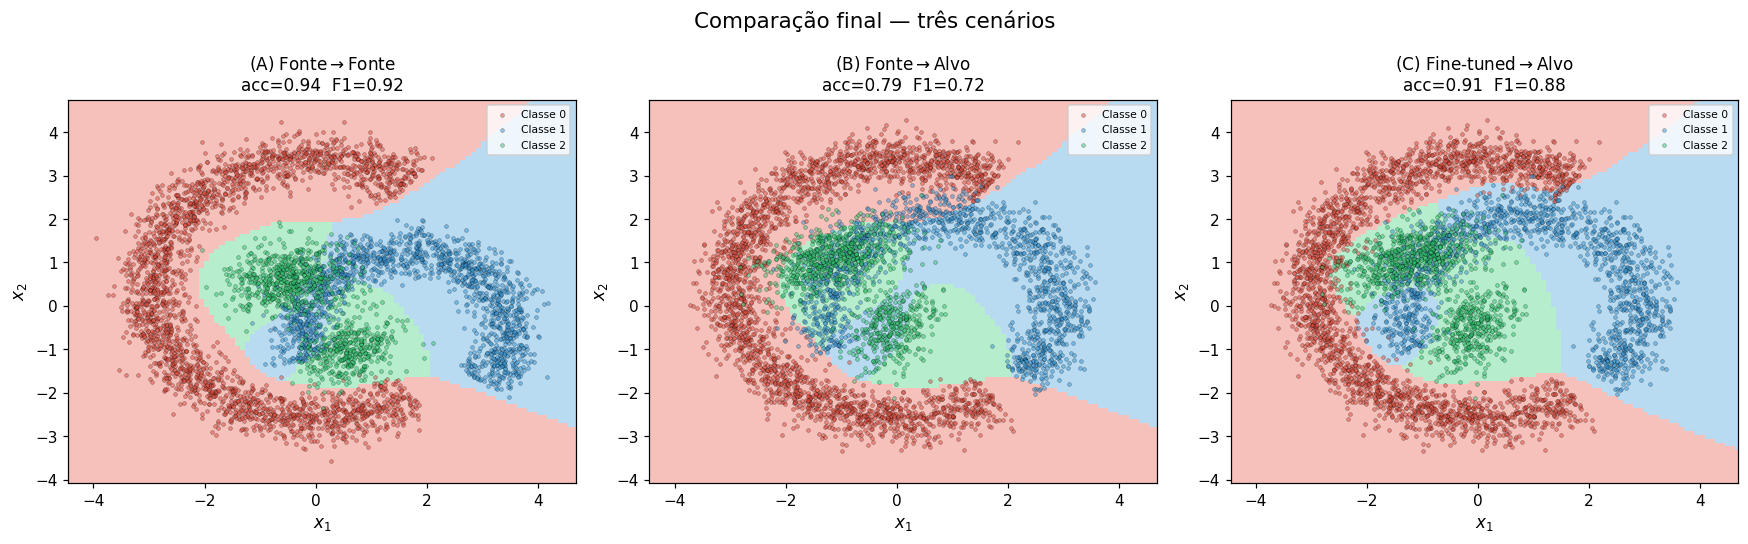

In [30]:
# Figura-síntese: 3 mapas de decisão
probs_malha_ft = probabilidades_malha(modelo_ft, xx, yy)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparação final — três cenários", fontsize=14)

plotar_mapa_decisao(axes[0], modelo, X_val, y_val, f"(A) Fonte$\\to$Fonte\nacc={acc_fonte:.2f}  F1={f1_fonte.mean():.2f}", xx, yy, probs=probs_malha)
axes[0].legend(fontsize=7, loc="upper right")

plotar_mapa_decisao(axes[1], modelo, X_alvo_val, y_alvo_val, f"(B) Fonte$\\to$Alvo\nacc={acc_alvo:.2f}  F1={f1_alvo.mean():.2f}", xx, yy, probs=probs_malha)
axes[1].legend(fontsize=7, loc="upper right")

plotar_mapa_decisao(axes[2], modelo_ft, X_alvo_val, y_alvo_val, f"(C) Fine-tuned$\\to$Alvo\nacc={acc_ft:.2f}  F1={f1_ft.mean():.2f}", xx, yy, probs=probs_malha_ft)
axes[2].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

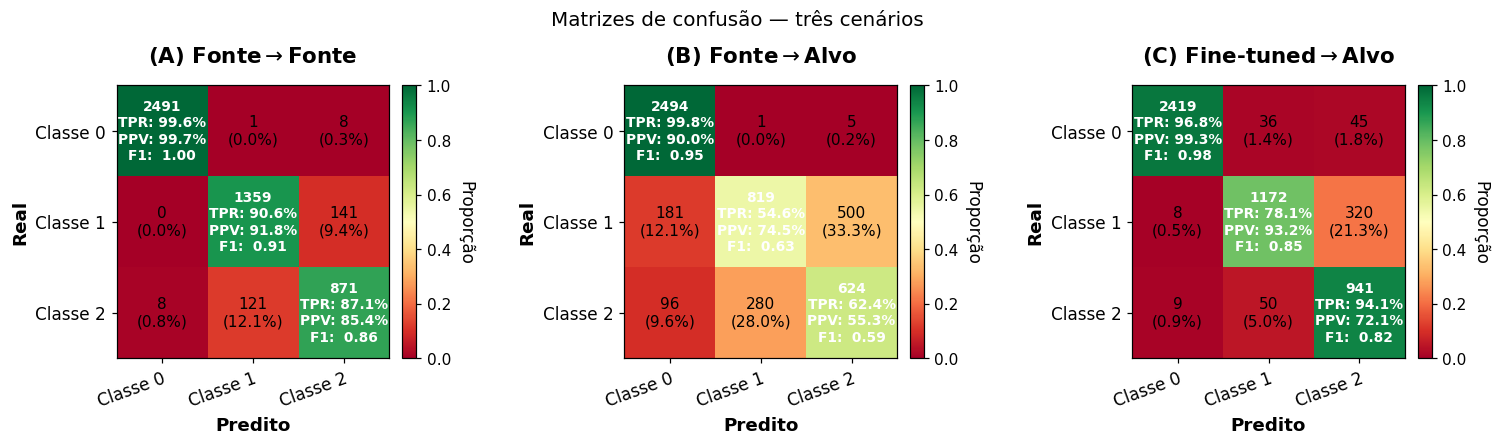

In [31]:
# Matrizes de confusão comparadas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Matrizes de confusão — três cenários", fontsize=13)
plotar_matriz_confusao(ax1, cm=cm_fonte, tpr=tpr_fonte, ppv=ppv_fonte, f1=f1_fonte, class_names=NOMES_CLASSES, title="(A) Fonte$\\to$Fonte")
plotar_matriz_confusao(ax2, cm=cm_alvo, tpr=tpr_alvo, ppv=ppv_alvo, f1=f1_alvo, class_names=NOMES_CLASSES, title="(B) Fonte$\\to$Alvo")
plotar_matriz_confusao(ax3, cm=cm_ft, tpr=tpr_ft, ppv=ppv_ft, f1=f1_ft, class_names=NOMES_CLASSES, title="(C) Fine-tuned$\\to$Alvo")
plt.tight_layout()
plt.show()

In [32]:
# Tabela-resumo de métricas
print("=" * 62)
print(f"{'Métrica':<14} {'(A) Fonte':>12} {'(B) Alvo':>12} {'(C) Fine-tuned':>14}")
print("=" * 62)
print(f"{'Acurácia':<14} {acc_fonte:>12.3f} {acc_alvo:>12.3f} {acc_ft:>14.3f}")
print(f"{'Macro-F1':<14} {f1_fonte.mean():>12.3f} {f1_alvo.mean():>12.3f} {f1_ft.mean():>14.3f}")
print("-" * 62)
for c in range(N_CLASSES):
    a_f = roc_fonte[c]["auc"] if roc_fonte[c]["auc"] is not None else 0
    a_a = roc_alvo[c]["auc"] if roc_alvo[c]["auc"] is not None else 0
    a_ft = roc_ft[c]["auc"] if roc_ft[c]["auc"] is not None else 0
    print(f"AUC {NOMES_CLASSES[c]:<9} {a_f:>12.3f} {a_a:>12.3f} {a_ft:>14.3f}")
print("-" * 62)
for c in range(N_CLASSES):
    print(f"F1  {NOMES_CLASSES[c]:<9} {f1_fonte[c]:>12.3f} {f1_alvo[c]:>12.3f} {f1_ft[c]:>14.3f}")
print("=" * 62)

Métrica           (A) Fonte     (B) Alvo (C) Fine-tuned
Acurácia              0.944        0.787          0.906
Macro-F1              0.924        0.721          0.882
--------------------------------------------------------------
AUC Classe 0         1.000        0.988          0.999
AUC Classe 1         0.991        0.920          0.981
AUC Classe 2         0.986        0.900          0.976
--------------------------------------------------------------
F1  Classe 0         0.997        0.946          0.980
F1  Classe 1         0.912        0.630          0.850
F1  Classe 2         0.862        0.586          0.816


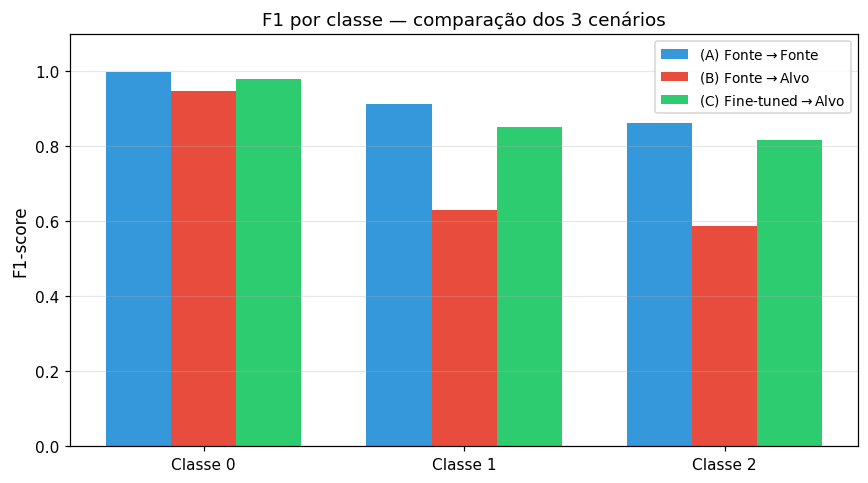

In [33]:
# Barplot comparativo de F1 por classe nos 3 cenários
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(N_CLASSES)
largura = 0.25

ax.bar(x_pos - largura, f1_fonte, largura, label="(A) Fonte$\\to$Fonte", color="#3498db")
ax.bar(x_pos, f1_alvo, largura, label="(B) Fonte$\\to$Alvo", color="#e74c3c")
ax.bar(x_pos + largura, f1_ft, largura, label="(C) Fine-tuned$\\to$Alvo", color="#2ecc71")

ax.set_xticks(x_pos)
ax.set_xticklabels(NOMES_CLASSES)
ax.set_ylim(0, 1.1)
ax.set_ylabel("F1-score")
ax.set_title("F1 por classe — comparação dos 3 cenários")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Takeaway

> **Domain shift degrada em silêncio; fine-tuning com poucos rótulos conserta.**

O que aprendemos:

1. Um modelo pode ter **alta confiança e estar errado** quando o domínio muda.
   Acurácia alta na fonte **não garante** bom desempenho no alvo.

2. **Métricas por classe** (TPR, F1, AUC) revelam degradações que a
   acurácia global esconde — especialmente em classes minoritárias.

3. **Fine-tuning supervisionado** com poucos rótulos do alvo é suficiente
   para recuperar grande parte do desempenho. Não precisamos re-treinar
   do zero: o conhecimento aprendido na fonte transfere.

Na próxima aula (L3), veremos como **aprendizado contrastivo** constrói
representações que são naturalmente mais robustas a mudanças de domínio.